In [ ]:
from cellpose import models
from cellpose.io import imread
import skimage
import os
import scipy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

- Move validation data to customized path

In [ ]:
test_path = '/scr/yren/mnfinder_validation'
output_test_path = '/scr/yren/mnfinder_new_test_data/'
os.makedirs(output_test_path, exist_ok=True)
for folder in tqdm(os.listdir(test_path)):
    if not '.DS_Store' in folder:
        for phenotype in os.listdir(f'{test_path}/{folder}/images/'):
            filename = phenotype.split('.')[0]
            filename = filename.replace(' ', '_')
            source = f'{test_path}/{folder}/images'
            destination = f'{output_test_path}/{folder}-{filename}.phenotype.tif'

            im = skimage.io.imread(f'{source}/{phenotype}')
            skimage.io.imsave(destination, im)

        for mn_mask in os.listdir(f'{test_path}/{folder}/mn_masks/'):
            filename = mn_mask.split('.')[0]
            filename = filename.replace(' ', '_')
            source = f'{test_path}/{folder}/mn_masks'
            destination = f'{output_test_path}/{folder}-{filename}.phenotype_outlines.png'

            im = skimage.io.imread(f'{source}/{mn_mask}')
            skimage.io.imsave(destination, im)

        for n_mask in os.listdir(f'{test_path}/{folder}/nucleus_masks/'):
            filename = n_mask.split('.')[0]
            filename = filename.replace(' ', '_')
            source = f'{test_path}/{folder}/nucleus_masks/'
            destination = f'{output_test_path}/{folder}-{filename}.nuclei.tif'
            
            im = skimage.io.imread(f'{source}/{n_mask}')
            skimage.io.imsave(destination, im)

# MNFinder Test Data

- The ground truth is different in mnfinder data (it's filled)

In [ ]:
images_dir = "/scr/yren/mnfinder_clean_data/testing/"
out_dir = images_dir

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
micron_files = [f"{images_dir}{x.replace('.tif','_outlines.png')}" for x in file_names]
nuclei_files = [out_dir + x.replace(".phenotype.tif",".nuclei.tif") for x in file_names]

total_overlap = 0
for m, n in zip(micron_files, nuclei_files):
    print(n.split("/")[-1])
    # Load micronuclei and nuclei masks
    mic_masks = skimage.io.imread(m) # 4 channel
    nuc_masks = skimage.io.imread(n)
    nuc_masks = np.mean(nuc_masks, axis=2) # 4 channel

    # Prepare micronuclei masks
    mask = np.mean(mic_masks, axis=2) > 0
    edge = skimage.filters.sobel(mask) > 0
    full_mic = mask + edge

    # Dilate micronuclei to obtain extra edges
    d = skimage.morphology.disk(2)
    dilated_obj = skimage.morphology.dilation(full_mic, d)
    dilated_edg = scipy.ndimage.binary_fill_holes(dilated_obj) ^ full_mic

    # Count objects and report differences
    obj = len(np.unique(skimage.morphology.label(mask)))
    full_obj = len(np.unique(skimage.morphology.label(full_mic)))
    dil_obj = len(np.unique(skimage.morphology.label(dilated_obj)))
    print(f"Without and with edges: {obj}(without) - {full_obj}(with) = {obj - full_obj}(diff)")
    print(f"With edges plus dilation: {full_obj}(edges) - {dil_obj}(dilated) = {full_obj - dil_obj}(diff)")

    # Find overlaps and remove them
    overlap = np.logical_and(full_mic, nuc_masks)
    total_overlap += np.sum(overlap)
    # print("Overlap:",np.sum(overlap))
    clean_nuclei = (nuc_masks>0) ^ overlap
    clean_labels = skimage.morphology.label(clean_nuclei)
    clean_labels = np.asarray(clean_labels, dtype="uint16")

    check_overlap = np.logical_and(full_mic, clean_labels)
    print(f'Overlap after cleaning: {np.unique(check_overlap)}')
    
    # Save result
    skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
    

2023-05-31_misc-MAX_2021_3_11_heladcas9_1_chr1CLING568_h2b488_40x.nuclei.tif
Without and with edges: 4(without) - 3(with) = 1(diff)
With edges plus dilation: 3(edges) - 3(dilated) = 0(diff)
Overlap after cleaning: [False]
2023-05-31_misc-MAX_2022-12-29_ATF3_tilescan.nuclei.tif
Without and with edges: 30(without) - 28(with) = 2(diff)
With edges plus dilation: 28(edges) - 26(dilated) = 2(diff)
Overlap after cleaning: [False]
2023-05-31_misc-HFF-revt-01_s18.nuclei.tif
Without and with edges: 24(without) - 23(with) = 1(diff)
With edges plus dilation: 23(edges) - 22(dilated) = 1(diff)
Overlap after cleaning: [False]
2023-05-31_misc-HFF-revt-01_s19.nuclei.tif
Without and with edges: 18(without) - 18(with) = 0(diff)
With edges plus dilation: 18(edges) - 18(dilated) = 0(diff)
Overlap after cleaning: [False]
2023-05-31_misc-MCC13_rfpcyto_w1cDAPI_s43.nuclei.tif


/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2021_3_11_heladcas9_1_chr1CLING568_h2b488_40x.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2022-12-29_ATF3_tilescan.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-HFF-revt-01_s18.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-HFF-revt-01_s19.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clea

Without and with edges: 6(without) - 6(with) = 0(diff)
With edges plus dilation: 6(edges) - 6(dilated) = 0(diff)
Overlap after cleaning: [False]
2023-05-31_misc-MAX_2021_3_25_hela_misseg_dcas9_1_chr1XCE568_DAPI_40x-0002.nuclei.tif
Without and with edges: 14(without) - 13(with) = 1(diff)
With edges plus dilation: 13(edges) - 11(dilated) = 2(diff)
Overlap after cleaning: [False]
2023-05-31_misc-MAX_2021_1_12_BAY18_CREST647_chr18_568_h3kac488_DAPI_20x-Series003-1.nuclei.tif
Without and with edges: 24(without) - 24(with) = 0(diff)
With edges plus dilation: 24(edges) - 24(dilated) = 0(diff)
Overlap after cleaning: [False]
2023-05-31_misc-HFF-revt-01_s5.nuclei.tif
Without and with edges: 12(without) - 12(with) = 0(diff)
With edges plus dilation: 12(edges) - 12(dilated) = 0(diff)
Overlap after cleaning: [False]
2023-05-31_misc-1.nuclei.tif


/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2021_3_25_hela_misseg_dcas9_1_chr1XCE568_DAPI_40x-0002.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2021_1_12_BAY18_CREST647_chr18_568_h3kac488_DAPI_20x-Series003-1.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-HFF-revt-01_s5.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-1.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.r

Without and with edges: 74(without) - 72(with) = 2(diff)
With edges plus dilation: 72(edges) - 70(dilated) = 2(diff)
Overlap after cleaning: [False]
2023-05-31_misc-MCC13_rfpcyto_w1cDAPI_s45.nuclei.tif
Without and with edges: 5(without) - 5(with) = 0(diff)
With edges plus dilation: 5(edges) - 5(dilated) = 0(diff)
Overlap after cleaning: [False]
2023-05-31_misc-MAX_2021_3_25_hela_misseg_dcas9_1_chr1XCE568_DAPI_40x.nuclei.tif
Without and with edges: 3(without) - 2(with) = 1(diff)
With edges plus dilation: 2(edges) - 2(dilated) = 0(diff)
Overlap after cleaning: [False]
2023-05-31_misc-MAX_2021_1_12_BAY18_CREST647_chr18_568_h3kac488_DAPI_20x-20x_DAPI.nuclei.tif


/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MCC13_rfpcyto_w1cDAPI_s45.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2021_3_25_hela_misseg_dcas9_1_chr1XCE568_DAPI_40x.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


Without and with edges: 63(without) - 56(with) = 7(diff)
With edges plus dilation: 56(edges) - 53(dilated) = 3(diff)
Overlap after cleaning: [False]
2023-05-31_misc-MAX_2022-12-29-0004.nuclei.tif
Without and with edges: 36(without) - 34(with) = 2(diff)
With edges plus dilation: 34(edges) - 33(dilated) = 1(diff)
Overlap after cleaning: [False]
2023-05-31_misc-HFF-revt-01_s17.nuclei.tif
Without and with edges: 17(without) - 14(with) = 3(diff)
With edges plus dilation: 14(edges) - 14(dilated) = 0(diff)
Overlap after cleaning: [False]
2023-05-31_misc-MCC13_rfpcyto_w1cDAPI_s47.nuclei.tif
Without and with edges: 2(without) - 2(with) = 0(diff)
With edges plus dilation: 2(edges) - 2(dilated) = 0(diff)
Overlap after cleaning: [False]
2022-10-14_U2OS-4.nuclei.tif


/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2021_1_12_BAY18_CREST647_chr18_568_h3kac488_DAPI_20x-20x_DAPI.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2022-12-29-0004.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-HFF-revt-01_s17.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MCC13_rfpcyto_w1cDAPI_s47.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.t

Without and with edges: 148(without) - 139(with) = 9(diff)
With edges plus dilation: 139(edges) - 119(dilated) = 20(diff)
Overlap after cleaning: [False]


/tmp/ipykernel_1642431/541829301.py:45: UserWarning: /scr/yren/mnfinder_clean_data/testing/2022-10-14_U2OS-4.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


- remeber to remove `nuclei.tif` files

# Test Example

In [14]:
micron_files

['/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2021_3_11_heladcas9_1_chr1CLING568_h2b488_40x.phenotype_outlines.png',
 '/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2022-12-29_ATF3_tilescan.phenotype_outlines.png',
 '/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-HFF-revt-01_s18.phenotype_outlines.png',
 '/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-HFF-revt-01_s19.phenotype_outlines.png',
 '/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MCC13_rfpcyto_w1cDAPI_s43.phenotype_outlines.png',
 '/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2021_3_25_hela_misseg_dcas9_1_chr1XCE568_DAPI_40x-0002.phenotype_outlines.png',
 '/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2021_1_12_BAY18_CREST647_chr18_568_h3kac488_DAPI_20x-Series003-1.phenotype_outlines.png',
 '/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-HFF-revt-01_s5.phenotype_outlines.png',
 '/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-1.phenotype_outl

(512, 512, 4)
/scr/yren/mnfinder_clean_data/testing/2023-05-31_misc-MAX_2021_3_11_heladcas9_1_chr1CLING568_h2b488_40x.phenotype_outlines.png


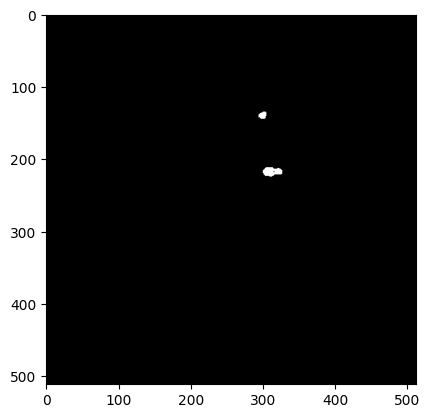

In [17]:
images_dir = "/scr/yren/mnfinder_clean_data/testing/"
out_dir = images_dir

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
micron_files = [f"{images_dir}{x.replace('.tif','_outlines.png')}" for x in file_names]
nuclei_files = [out_dir + x.replace(".phenotype.tif",".nuclei-clean.tif") for x in file_names]

# Load micronuclei and nuclei masks
mic_masks = skimage.io.imread(micron_files[0])
nuc_masks = skimage.io.imread(nuclei_files[0])
print(mic_masks.shape)
mask = np.mean(mic_masks, axis=2) > 0
edge = skimage.filters.sobel(mask) > 0
full_mic = mask + edge

print(micron_files[0])
plt.imshow(full_mic, cmap="gray")

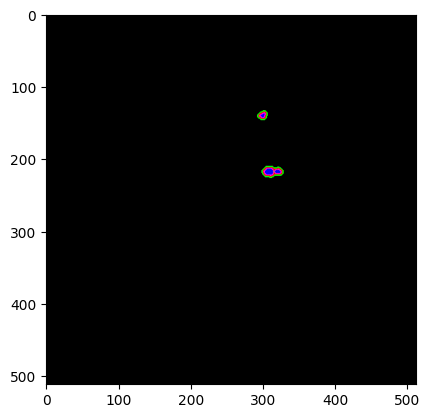

In [18]:
d = skimage.morphology.disk(2)
dilated_obj = skimage.morphology.dilation(full_mic, d) # dilated micronuclei mask
dilated_edg = scipy.ndimage.binary_fill_holes(dilated_obj) ^ full_mic

edg_mask = np.concatenate([255*edge[:,:,None], 255*dilated_edg[:,:,None], 255*mask[:,:,None]], axis=2)
plt.imshow(edg_mask[:,:], cmap="gray")

In [19]:
bright_pixel = np.array([[0, 0, 0, 0, 0],
                         [0, 0, 0, 0, 0],
                         [0, 0, 1, 0, 0],
                         [0, 0, 0, 0, 0],
                         [0, 0, 0, 0, 0]], dtype=np.uint8)
skimage.morphology.dilation(bright_pixel, d)

array([[0, 0, 1, 0, 0],
       [0, 1, 1, 1, 0],
       [1, 1, 1, 1, 1],
       [0, 1, 1, 1, 0],
       [0, 0, 1, 0, 0]], dtype=uint8)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..2295].


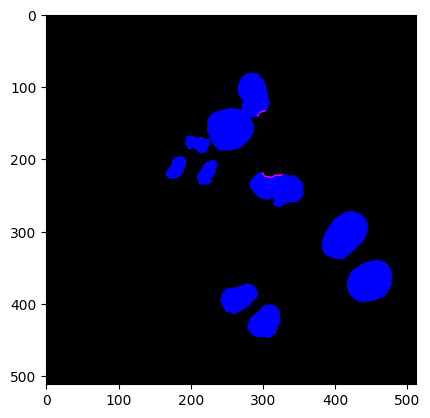

In [20]:
overlap = np.logical_and(dilated_obj, nuc_masks) # whether both operands are True (only T & T --> T)
view = np.concatenate([255*overlap[:,:,None], np.zeros_like(mask)[:,:,None], 255*nuc_masks[:,:,None]], axis=2)
plt.imshow(view[:,:,:], cmap="gray")

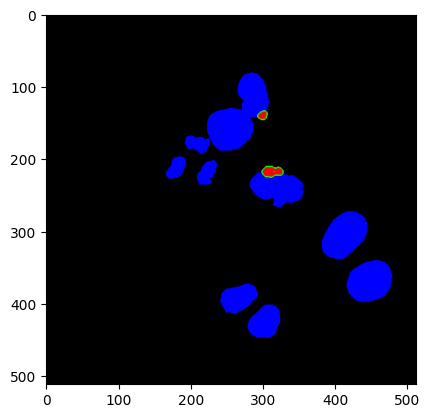

In [21]:
clean_nuclei = (nuc_masks>0) ^ overlap
view = np.concatenate([1.*full_mic[:,:,None], 1*dilated_edg[:,:,None], 1.*clean_nuclei[:,:,None]], axis=2)
plt.imshow(view[:,:,:])

In [ ]:
x = np.array([
    [False,True,False],
    [True,True,True],
    [False,False,False],
])
y = np.array([
    [False,True,False],
    [True,True,True],
    [False,False,False],
])
np.logical_and(x,y)

# Train Data

In [31]:
images_dir = "/scr/yren/mnfinder_clean_data/training/"
out_dir = images_dir

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
micron_files = [f"{images_dir}{x.replace('.tif','_outlines.png')}" for x in file_names]
nuclei_files = [out_dir + x.replace(".phenotype.tif",".nuclei.tif") for x in file_names]

total_overlap = 0
for m, n in zip(micron_files, nuclei_files):
    print(n.split("/")[-1])
    # Load micronuclei and nuclei masks
    mic_masks = skimage.io.imread(m) # here is for mnfinder data
    nuc_masks = skimage.io.imread(n)
    nuc_masks = np.mean(nuc_masks, axis=2)
    
    # Prepare micronuclei masks training data
    mask = np.mean(mic_masks, axis=2) > 0
    edge = skimage.filters.sobel(mask) > 0
    full_mic = mask + edge

    # Dilate micronuclei to obtain extra edges
    d = skimage.morphology.disk(2)
    dilated_obj = skimage.morphology.dilation(full_mic, d)
    dilated_edg = scipy.ndimage.binary_fill_holes(dilated_obj) ^ full_mic

    # Count objects and report differences
    obj = len(np.unique(skimage.morphology.label(mask)))
    full_obj = len(np.unique(skimage.morphology.label(full_mic)))
    dil_obj = len(np.unique(skimage.morphology.label(dilated_obj)))
    # print(f"Without and with edges: {obj}(without) - {full_obj}(with) = {obj - full_obj}(diff)")
    # print(f"With edges plus dilation: {full_obj}(edges) - {dil_obj}(dilated) = {full_obj - dil_obj}(diff)")

    # Find overlaps and remove them
    overlap = np.logical_and(full_mic, nuc_masks)
    total_overlap += np.sum(overlap)
    # print("Overlap:",np.sum(overlap))
    clean_nuclei = (nuc_masks>0) ^ overlap
    clean_labels = skimage.morphology.label(clean_nuclei)
    clean_labels = np.asarray(clean_labels, dtype="uint16")

    check_overlap = np.logical_and(full_mic, clean_labels)
    print(f'Overlap after cleaning: {np.unique(check_overlap)}')
    
    # Save result
    skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


2022-05-27_RPE1-3.nuclei.tif
Overlap after cleaning: [False]
2022-05-27_RPE1-1.nuclei.tif


/tmp/ipykernel_1642431/1969056694.py:45: UserWarning: /scr/yren/mnfinder_clean_data/training/2022-05-27_RPE1-3.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/1969056694.py:45: UserWarning: /scr/yren/mnfinder_clean_data/training/2022-05-27_RPE1-1.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


Overlap after cleaning: [False]
2022-05-27_RPE1-2197.nuclei.tif
Overlap after cleaning: [False]
2022-03-18_RPE1-3.nuclei.tif


/tmp/ipykernel_1642431/1969056694.py:45: UserWarning: /scr/yren/mnfinder_clean_data/training/2022-05-27_RPE1-2197.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/1969056694.py:45: UserWarning: /scr/yren/mnfinder_clean_data/training/2022-03-18_RPE1-3.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


Overlap after cleaning: [False]
2022-03-18_RPE1-5.nuclei.tif
Overlap after cleaning: [False]
2022-03-18_RPE1-4.nuclei.tif


...

/tmp/ipykernel_1642431/1969056694.py:45: UserWarning: /scr/yren/mnfinder_clean_data/training/2022-10-14_U2OS-5.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/1969056694.py:45: UserWarning: /scr/yren/mnfinder_clean_data/training/2022-10-14_U2OS-7.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


Overlap after cleaning: [False]
2022-05-25_RPE1-2.nuclei.tif
Overlap after cleaning: [False]
2022-05-25_RPE1-1.nuclei.tif


/tmp/ipykernel_1642431/1969056694.py:45: UserWarning: /scr/yren/mnfinder_clean_data/training/2022-05-25_RPE1-3.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_1642431/1969056694.py:45: UserWarning: /scr/yren/mnfinder_clean_data/training/2022-05-25_RPE1-2.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


Overlap after cleaning: [False]


/tmp/ipykernel_1642431/1969056694.py:45: UserWarning: /scr/yren/mnfinder_clean_data/training/2022-05-25_RPE1-1.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)


# Train Example

In [ ]:
images_dir = "./mnfinder_training/"
out_dir = images_dir

file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
micron_files = [f"{images_dir}{x.replace('.tif','_outlines.png')}" for x in file_names]
nuclei_files = [out_dir + x.replace(".phenotype.tif",".nuclei.tif") for x in file_names]

# Load micronuclei and nuclei masks
mic_masks = skimage.io.imread(micron_files[0])
nuc_masks = skimage.io.imread(nuclei_files[0])

nuc_masks = nuc_masks[:,:,1]
print(mic_masks.shape)
mask = np.mean(mic_masks, axis=2) > 0

# edge = skimage.filters.sobel(mask) > 0
# # edge = mic_masks[:,:,0] > 0 # Use only the red channel
# mask = scipy.ndimage.binary_fill_holes(edge) ^ edge
full_mic = mask

plt.imshow(full_mic[300:700,300:700], cmap="gray")

In [ ]:
d = skimage.morphology.disk(2)
dilated_obj = skimage.morphology.dilation(full_mic, d) # dilated micronuclei mask
dilated_edg = scipy.ndimage.binary_fill_holes(dilated_obj) ^ full_mic

edg_mask = np.concatenate([np.zeros_like(mask)[:,:,None], 255*dilated_edg[:,:,None], 255*mask[:,:,None]], axis=2)
plt.imshow(edg_mask[300:700,300:700,:], cmap="gray")

In [ ]:
overlap = np.logical_and(dilated_obj, nuc_masks) # whether both operands are True (only T & T --> T)
view = np.concatenate([255*overlap[:,:,None], np.zeros_like(mask)[:,:,None], 1*nuc_masks[:,:,None]], axis=2)
plt.imshow(view[300:700,300:700,:], cmap='gray')

In [ ]:
clean_nuclei = (nuc_masks>0) ^ overlap
view = np.concatenate([1.*full_mic[:,:,None], 1*dilated_edg[:,:,None], 1.*clean_nuclei[:,:,None]], axis=2)
plt.imshow(view[300:700,300:700,:])